# Main Analysis

This notebook reproduces the aggregate tables, statistical tests, and figures for the Dark Triad response-distortion analysis. It reads curated item-level model outputs from `Data/`, writes derived CSV files to `Results/`, and writes generated figures to `Plots/`.

Percentages are computed over valid classified responses (`High / (High + Low)`), with `Unknown` responses summarized separately as omissions/non-classifiable outputs.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.gridspec import GridSpec
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

In [2]:
# Project paths
DATA_DIR = Path("Data")
RESULTS_DIR = Path("Results")
PLOTS_DIR = Path("Plots")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

HIGH_PERCENT_PATH = RESULTS_DIR / "all_models_high_percentages.csv"
DELTAS_PATH = RESULTS_DIR / "all_models_deltas.csv"
MCNEMAR_PATH = RESULTS_DIR / "mcnemar_results_all_models.csv"

TRAITS = ["Machiavellianism", "Narcissism", "Psychopathy"]
TRAIT_LABELS_SHORT = ["Mach.", "Narc.", "Psych."]

CONDITION_ORDER = [
    "SA",
    "FG_job",
    "FG_legal",
    "FB_job",
    "FB_legal",
    "FB_job_expl",
    "FB_legal_expl",
]

IMPLICIT_CONDITIONS = ["SA", "FG_job", "FG_legal", "FB_job", "FB_legal"]
EXPLICIT_CONDITIONS = ["FB_job_expl", "FB_legal_expl"]
MCNEMAR_COMPARISONS = [
    ("FG_job", "SA"),
    ("FG_legal", "SA"),
    ("FB_job", "SA"),
    ("FB_legal", "SA"),
]

MODEL_FOLDERS = {
    "GPT-4.1": "GPT4_1",
    "Grok-4.3": "Grok4_3",
    "DeepSeek-V3.2": "DeepseekV3_2",
    "Mistral Large 3": "Mistral_Large3",
    "Gemma 3": "Gemma3",
    "Llama 3.3": "Llama3_3",
    "Qwen 2.5": "Qwen2_5",
}

MODEL_ORDER = list(MODEL_FOLDERS)


def condition_path(model_folder, condition):
    """Return the CSV path for a model/condition pair."""
    if condition.endswith("_expl"):
        public_condition = condition.removesuffix("_expl")
        return DATA_DIR / model_folder / "explicit" / f"{public_condition}.csv"
    return DATA_DIR / model_folder / f"{condition}.csv"


def build_model_files(conditions):
    """Build the nested model -> condition -> file map from the public Data/ layout."""
    return {
        model_name: {
            condition: condition_path(model_folder, condition)
            for condition in conditions
        }
        for model_name, model_folder in MODEL_FOLDERS.items()
    }


MODEL_FILES = build_model_files(CONDITION_ORDER)
MCNEMAR_MODEL_FILES = build_model_files(IMPLICIT_CONDITIONS)


def require_columns(df, columns, path):
    missing = set(columns) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns {sorted(missing)} in {path}")


def save_plot(stem, **kwargs):
    """Save the active Matplotlib figure as equivalent PDF and EPS files."""
    for file_format in ("pdf", "eps"):
        plt.savefig(
            PLOTS_DIR / f"{stem}.{file_format}",
            format=file_format,
            **kwargs,
        )


# Compute high-response percentages.
rows = []

for model_name, condition_files in MODEL_FILES.items():
    for condition, file_path in condition_files.items():
        print(f"Processing: {model_name} | {condition}")

        if not file_path.exists():
            raise FileNotFoundError(f"Missing input file: {file_path}")

        df = pd.read_csv(file_path)
        require_columns(df, {"personality", "choice_type"}, file_path)

        for trait in TRAITS:
            sub = df[df["personality"] == trait]

            high = int((sub["choice_type"] == "High").sum())
            low = int((sub["choice_type"] == "Low").sum())
            unknown = int((sub["choice_type"] == "Unknown").sum())

            total = high + low + unknown
            valid_total = high + low
            p_high = high / valid_total if valid_total > 0 else np.nan

            rows.append({
                "model": model_name,
                "condition": condition,
                "trait": trait,
                "High": high,
                "Low": low,
                "Unknown": unknown,
                "Total": total,
                "Valid_Total": valid_total,
                "p_high": p_high,
                "high_percent": p_high * 100 if valid_total > 0 else np.nan,
                "unknown_percent": unknown / total * 100 if total > 0 else np.nan,
            })

summary_df = pd.DataFrame(rows)
summary_df["condition"] = pd.Categorical(
    summary_df["condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)
summary_df = summary_df.sort_values(["model", "trait", "condition"]).reset_index(drop=True)
summary_df.to_csv(HIGH_PERCENT_PATH, index=False)

print(f"Saved high-response summary to: {HIGH_PERCENT_PATH}")

summary_display = summary_df.copy()
summary_display["p_high"] = summary_display["p_high"].round(3)
summary_display["high_percent"] = summary_display["high_percent"].round(2)
summary_display["unknown_percent"] = summary_display["unknown_percent"].round(3)
summary_display

Processing: GPT-4.1 | SA
Processing: GPT-4.1 | FG_job
Processing: GPT-4.1 | FG_legal
Processing: GPT-4.1 | FB_job
Processing: GPT-4.1 | FB_legal
Processing: GPT-4.1 | FB_job_expl
Processing: GPT-4.1 | FB_legal_expl
Processing: Grok-4.3 | SA
Processing: Grok-4.3 | FG_job
Processing: Grok-4.3 | FG_legal
Processing: Grok-4.3 | FB_job
Processing: Grok-4.3 | FB_legal
Processing: Grok-4.3 | FB_job_expl
Processing: Grok-4.3 | FB_legal_expl
Processing: DeepSeek-V3.2 | SA
Processing: DeepSeek-V3.2 | FG_job
Processing: DeepSeek-V3.2 | FG_legal
Processing: DeepSeek-V3.2 | FB_job
Processing: DeepSeek-V3.2 | FB_legal
Processing: DeepSeek-V3.2 | FB_job_expl
Processing: DeepSeek-V3.2 | FB_legal_expl
Processing: Mistral Large 3 | SA
Processing: Mistral Large 3 | FG_job
Processing: Mistral Large 3 | FG_legal
Processing: Mistral Large 3 | FB_job
Processing: Mistral Large 3 | FB_legal
Processing: Mistral Large 3 | FB_job_expl
Processing: Mistral Large 3 | FB_legal_expl
Processing: Gemma 3 | SA
Processing

Processing: Gemma 3 | FB_job_expl
Processing: Gemma 3 | FB_legal_expl
Processing: Llama 3.3 | SA
Processing: Llama 3.3 | FG_job
Processing: Llama 3.3 | FG_legal
Processing: Llama 3.3 | FB_job
Processing: Llama 3.3 | FB_legal
Processing: Llama 3.3 | FB_job_expl
Processing: Llama 3.3 | FB_legal_expl
Processing: Qwen 2.5 | SA
Processing: Qwen 2.5 | FG_job
Processing: Qwen 2.5 | FG_legal
Processing: Qwen 2.5 | FB_job
Processing: Qwen 2.5 | FB_legal
Processing: Qwen 2.5 | FB_job_expl
Processing: Qwen 2.5 | FB_legal_expl
Saved high-response summary to: Results/all_models_high_percentages.csv


,model,condition,trait,High,Low,Unknown,Total,Valid_Total,p_high,high_percent,unknown_percent
0,DeepSeek-V3.2,SA,Machiavellianism,129,871,0,1000,1000,0.129,12.90,0.0
1,DeepSeek-V3.2,FG_job,Machiavellianism,117,882,1,1000,999,0.117,11.71,0.1
2,DeepSeek-V3.2,FG_legal,Machiavellianism,121,879,0,1000,1000,0.121,12.10,0.0
3,DeepSeek-V3.2,FB_job,Machiavellianism,253,747,0,1000,1000,0.253,25.30,0.0
4,DeepSeek-V3.2,FB_legal,Machiavellianism,147,852,1,1000,999,0.147,14.71,0.1
...,...,...,...,...,...,...,...,...,...,...,...
142,Qwen 2.5,FG_legal,Psychopathy,0,999,1,1000,999,0.000,0.00,0.1
143,Qwen 2.5,FB_job,Psychopathy,3,997,0,1000,1000,0.003,0.30,0.0
144,Qwen 2.5,FB_legal,Psychopathy,32,968,0,1000,1000,0.032,3.20,0.0
145,Qwen 2.5,FB_job_expl,Psychopathy,335,650,15,1000,985,0.340,34.01,1.5


In [3]:
# Compute condition deltas relative to self-assessment.
df_long = pd.read_csv(HIGH_PERCENT_PATH)

print("Conditions found:")
print(sorted(df_long["condition"].unique()))

df_pivot = (
    df_long
    .pivot_table(
        index=["trait", "model"],
        columns="condition",
        values="high_percent",
    )
    .reset_index()
    .rename(columns={"trait": "Trait", "model": "Model"})
)
df_pivot.columns.name = None

for condition in ["FG_job", "FG_legal", "FB_job", "FB_legal", "FB_job_expl", "FB_legal_expl"]:
    df_pivot[f"Δ{condition}"] = df_pivot[condition] - df_pivot["SA"]

cols = [
    "Trait",
    "Model",
    "SA",
    "FG_job",
    "FG_legal",
    "FB_job",
    "FB_legal",
    "FB_job_expl",
    "FB_legal_expl",
    "ΔFG_job",
    "ΔFG_legal",
    "ΔFB_job",
    "ΔFB_legal",
    "ΔFB_job_expl",
    "ΔFB_legal_expl",
]

df_pivot = df_pivot[cols].sort_values(["Trait", "Model"]).reset_index(drop=True)

numeric_cols = df_pivot.select_dtypes(include="number").columns
df_pivot[numeric_cols] = df_pivot[numeric_cols].round(1)

df_pivot.to_csv(DELTAS_PATH, index=False)

print(f"Saved delta table to: {DELTAS_PATH}")
display(df_pivot)

Conditions found:
['FB_job', 'FB_job_expl', 'FB_legal', 'FB_legal_expl', 'FG_job', 'FG_legal', 'SA']
Saved delta table to: Results/all_models_deltas.csv


,Trait,Model,SA,FG_job,FG_legal,FB_job,FB_legal,FB_job_expl,FB_legal_expl,ΔFG_job,ΔFG_legal,ΔFB_job,ΔFB_legal,ΔFB_job_expl,ΔFB_legal_expl
0,Machiavellianism,DeepSeek-V3.2,12.9,11.7,12.1,25.3,14.7,92.2,43.7,-1.2,-0.8,12.4,1.8,79.3,30.8
1,Machiavellianism,GPT-4.1,15.3,7.6,11.1,25.0,12.2,97.9,55.3,-7.7,-4.2,9.7,-3.1,82.6,40.0
2,Machiavellianism,Gemma 3,16.2,12.0,16.4,18.9,17.9,96.3,38.9,-4.2,0.2,2.7,1.7,80.1,22.7
3,Machiavellianism,Grok-4.3,15.3,6.9,12.6,30.1,14.3,94.8,39.3,-8.4,-2.7,14.8,-1.0,79.5,24.0
4,Machiavellianism,Llama 3.3,11.1,7.3,8.6,13.7,9.3,92.8,28.4,-3.8,-2.5,2.6,-1.8,81.7,17.3
5,Machiavellianism,Mistral Large 3,18.5,12.1,17.5,29.0,18.4,92.1,37.6,-6.4,-1.0,10.5,-0.1,73.6,19.1
6,Machiavellianism,Qwen 2.5,12.9,12.4,12.7,22.1,22.4,77.4,15.7,-0.5,-0.2,9.2,9.5,64.5,2.8
7,Narcissism,DeepSeek-V3.2,6.2,5.1,5.7,10.6,6.6,86.7,45.1,-1.1,-0.5,4.4,0.4,80.5,38.9
8,Narcissism,GPT-4.1,7.6,2.9,5.1,9.2,5.6,96.1,62.3,-4.7,-2.5,1.6,-2.0,88.5,54.7
9,Narcissism,Gemma 3,6.5,4.4,6.4,5.8,7.1,87.5,24.4,-2.1,-0.1,-0.7,0.6,81.0,17.9


In [4]:
# Data completeness check: each condition should be available for every model.
summary_df.groupby("condition")["model"].nunique()

condition
SA               7
FG_job           7
FG_legal         7
FB_job           7
FB_legal         7
FB_job_expl      7
FB_legal_expl    7
Name: model, dtype: int64

## Self-assessment distribution by trait


/tmp/ipykernel_1571401/2107272709.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


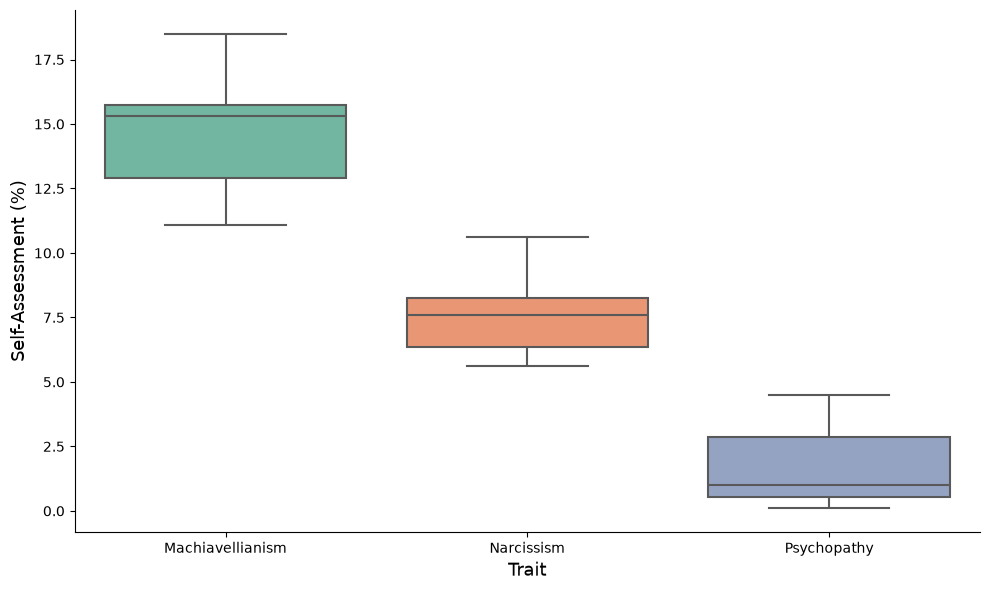

In [5]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_pivot,
    x="Trait",
    y="SA",
    palette="Set2",
    showfliers=False,
    linewidth=1.5,
)

plt.xlabel("Trait", fontsize=13)
plt.ylabel("Self-Assessment (%)", fontsize=13)
plt.xticks(rotation=0)

sns.despine()
plt.tight_layout()

save_plot("self_assessment_distribution", bbox_inches="tight")

plt.show()

## Self-assessment by model and trait


Traits in df_pivot:
['Machiavellianism', 'Narcissism', 'Psychopathy']

Models in df_pivot:
['DeepSeek-V3.2', 'GPT-4.1', 'Gemma 3', 'Grok-4.3', 'Llama 3.3', 'Mistral Large 3', 'Qwen 2.5']

Models not in model order: set()
Traits not in trait order: set()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


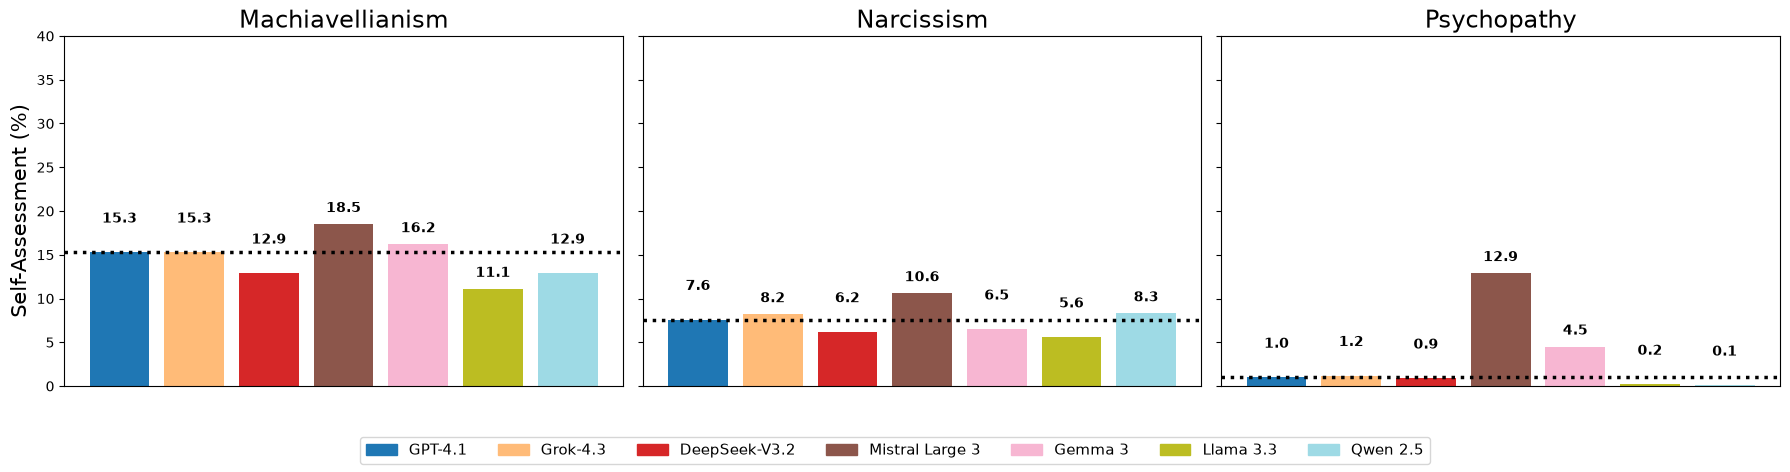

In [6]:
models = MODEL_ORDER

print("Traits in df_pivot:")
print(sorted(df_pivot["Trait"].unique()))
print("\nModels in df_pivot:")
print(sorted(df_pivot["Model"].unique()))

missing_models = set(df_pivot["Model"].unique()) - set(models)
missing_traits = set(df_pivot["Trait"].unique()) - set(TRAITS)
print("\nModels not in model order:", missing_models)
print("Traits not in trait order:", missing_traits)

cmap = plt.colormaps.get_cmap("tab20").resampled(len(models))
model_to_color = {model: cmap(i) for i, model in enumerate(models)}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, trait in zip(axes, TRAITS):
    df_t = df_pivot[df_pivot["Trait"] == trait].copy()
    df_t = df_t[df_t["Model"].isin(models)].copy()

    if df_t.empty:
        ax.set_title(f"{trait}\n(no data)", fontsize=17)
        ax.set_xticks([])
        continue

    df_t["Model"] = pd.Categorical(df_t["Model"], categories=models, ordered=True)
    df_t = df_t.sort_values("Model")

    x = np.arange(len(df_t))
    heights = df_t["SA"].astype(float).values
    colors = [model_to_color[str(model)] for model in df_t["Model"]]

    bars = ax.bar(x, heights, color=colors)
    median_val = np.median(heights)
    ax.axhline(median_val, color="black", linestyle=":", linewidth=2.5)

    for bar, value in zip(bars, heights):
        y_text = value + 1
        if abs(y_text - median_val) < 1.5:
            y_text = value + 3
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_text,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_title(trait, fontsize=17)
    ax.set_ylim(0, 40)
    ax.set_xticks([])

    if ax is axes[0]:
        ax.set_ylabel("Self-Assessment (%)", fontsize=15)

handles = [plt.Rectangle((0, 0), 1, 1, color=model_to_color[model]) for model in models]
fig.legend(handles, models, loc="lower center", ncol=len(models), fontsize=11)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
save_plot("self_assessment_by_model", bbox_inches="tight")
plt.show()

## Condition shifts relative to self-assessment


Traits in df_plot:
['Machiavellianism', 'Narcissism', 'Psychopathy']

Models in df_plot:
['DeepSeek-V3.2', 'GPT-4.1', 'Gemma 3', 'Grok-4.3', 'Llama 3.3', 'Mistral Large 3', 'Qwen 2.5']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


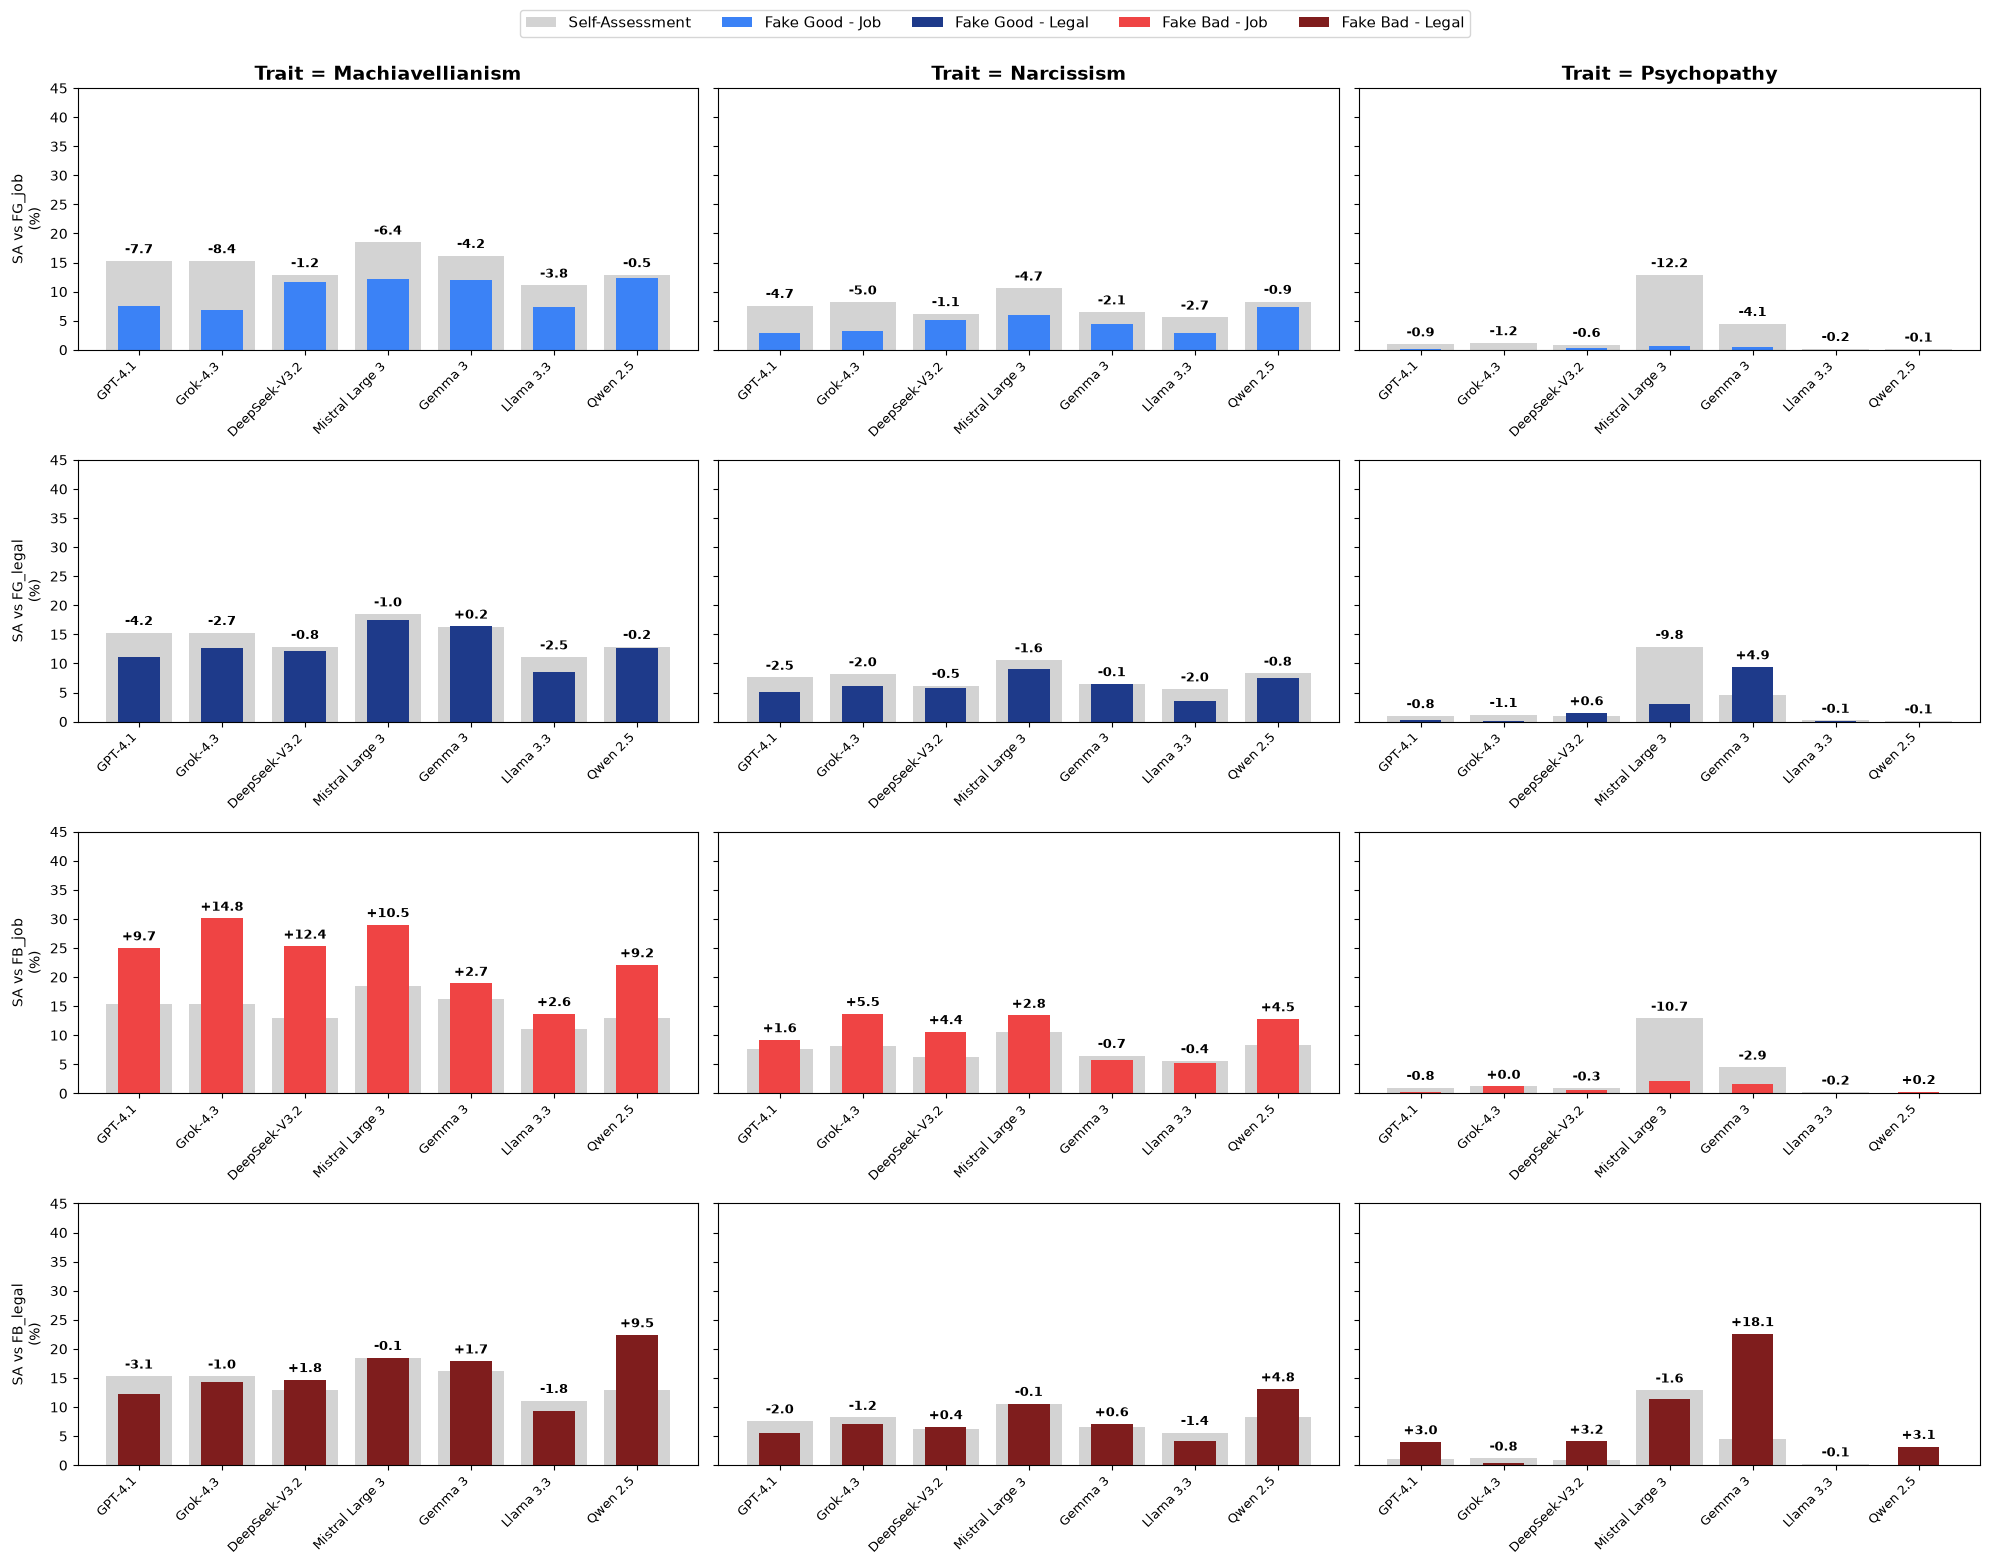

In [7]:
# =========================
# OUTPUT FOLDER
# =========================

# =========================
# STARTING DATAFRAME
# =========================

df_plot = df_pivot.copy()

# Values are already percentages on a 0-100 scale, so do not multiply by 100
value_cols = ["SA", "FG_job", "FG_legal", "FB_job", "FB_legal"]

# Use this only if values are proportions on a 0-1 scale
# df_percent[value_cols] = df_percent[value_cols] * 100

# =========================
# CHECK
# =========================

print("Traits in df_plot:")
print(sorted(df_plot["Trait"].unique()))

print("\nModels in df_plot:")
print(sorted(df_plot["Model"].unique()))

# =========================
# PLOT SETTINGS
# =========================

traits = TRAITS

models = MODEL_ORDER

sa_color = "lightgray"

fg_job_color   = "#3B82F6"
fg_legal_color = "#1E3A8A"

fb_job_color   = "#EF4444"
fb_legal_color = "#7F1D1D"

fig, axes = plt.subplots(
    4,
    3,
    figsize=(20, 16),
    sharey=True
)

row_specs = [
    ("FG_job",   "SA vs FG_job",   fg_job_color,   "Fake Good - Job"),
    ("FG_legal", "SA vs FG_legal", fg_legal_color, "Fake Good - Legal"),
    ("FB_job",   "SA vs FB_job",   fb_job_color,   "Fake Bad - Job"),
    ("FB_legal", "SA vs FB_legal", fb_legal_color, "Fake Bad - Legal"),
]

# =========================
# PLOT
# =========================

for j, trait in enumerate(traits):

    df_t = df_plot[df_plot["Trait"] == trait].copy()

    df_t["Model"] = pd.Categorical(
        df_t["Model"],
        categories=models,
        ordered=True
    )

    df_t = df_t.sort_values("Model")

    # Keep only valid models
    df_t = df_t[df_t["Model"].notna()].copy()

    x = np.arange(len(df_t))
    model_labels = df_t["Model"].astype(str).tolist()

    sa = df_t["SA"].astype(float).values

    for i, (cond_col, ylab, cond_color, cond_label) in enumerate(row_specs):

        ax = axes[i, j]

        cond_vals = df_t[cond_col].astype(float).values

        ax.bar(
            x,
            sa,
            width=0.8,
            color=sa_color,
            label="Self-Assessment"
        )

        ax.bar(
            x,
            cond_vals,
            width=0.5,
            color=cond_color,
            label=cond_label
        )

        for xi, s_val, c_val in zip(x, sa, cond_vals):

            delta = c_val - s_val

            ax.text(
                xi,
                max(s_val, c_val) + 0.8,
                f"{delta:+.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black"
            )

        if i == 0:
            ax.set_title(
                f"Trait = {trait}",
                fontsize=14,
                fontweight="bold"
            )

        ax.set_xticks(x)
        ax.set_xticklabels(
            model_labels,
            rotation=45,
            ha="right",
            fontsize=9
        )

        ax.set_ylim(0, 45)

        if j == 0:
            ax.set_ylabel(f"{ylab}\n(%)")
        else:
            ax.set_ylabel("")

# =========================
# SHARED LEGEND
# =========================

handles, labels = [], []

for ax in axes.ravel():

    h, l = ax.get_legend_handles_labels()

    for hh, ll in zip(h, l):

        if ll and ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=5,
    fontsize=11
)

# =========================
# LAYOUT AND SAVE
# =========================

plt.tight_layout(rect=[0, 0, 1, 0.95])

save_plot("condition_shifts_by_context", bbox_inches="tight")

plt.show()

## Radar plots for implicit conditions


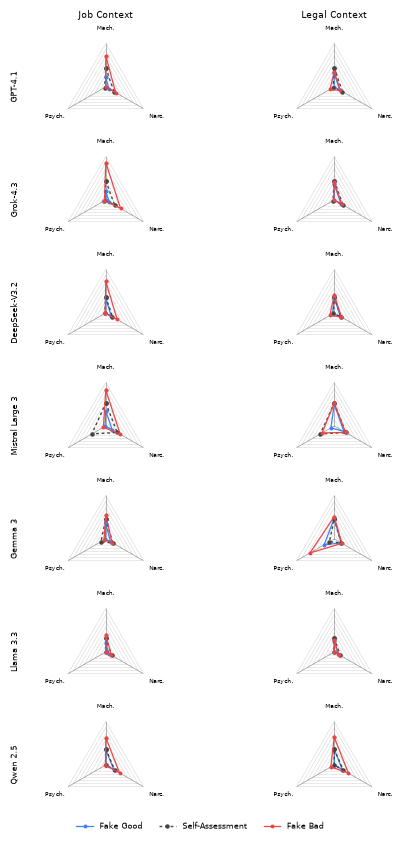

In [8]:
# =========================
# DATA
# =========================

df_percent = df_pivot.copy()

traits = TRAITS
trait_labels = TRAIT_LABELS_SHORT

models = MODEL_ORDER

N = len(traits)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

plot_sets = {
    "job": {
        "conditions": ["FG_job", "SA", "FB_job"],
        "colors": {
            "FG_job": "#3B82F6",
            "SA": "#444444",
            "FB_job": "#EF4444"
        },
        "labels": {"title": "Job Context"}
    },
    "legal": {
        "conditions": ["FG_legal", "SA", "FB_legal"],
        "colors": {
            "FG_legal": "#3B82F6",
            "SA": "#444444",
            "FB_legal": "#EF4444"
        },
        "labels": {"title": "Legal Context"}
    }
}

legend_names = {
    "FG_job": "Fake Good",
    "FG_legal": "Fake Good",
    "SA": "Self-Assessment",
    "FB_job": "Fake Bad",
    "FB_legal": "Fake Bad"
}

# =========================
# FIGURE
# =========================

fig, axes = plt.subplots(
    7,
    2,
    figsize=(5, 8.5),
    subplot_kw=dict(polar=True)
)

contexts = [
    ("job", plot_sets["job"]),
    ("legal", plot_sets["legal"])
]

for row, model in enumerate(models):

    df_m = df_percent[df_percent["Model"] == model].copy()

    df_m["Trait"] = pd.Categorical(
        df_m["Trait"],
        categories=traits,
        ordered=True
    )

    df_m = df_m.sort_values("Trait")

    for col, (context_name, cfg) in enumerate(contexts):

        ax = axes[row, col]

        conditions = cfg["conditions"]
        colors = cfg["colors"]
        labels = cfg["labels"]

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)

        ax.grid(False)
        ax.spines["polar"].set_visible(False)

        max_val = 35
        ax.set_ylim(0, max_val)

        grid_levels = np.arange(5, 36, 5)

        for level in grid_levels:
            ax.plot(
                angles_closed,
                np.repeat(level, N + 1),
                color="#d3d3d3",
                linewidth=0.35,
                zorder=0
            )

        for angle in angles:
            ax.plot(
                [angle, angle],
                [0, max_val],
                color="#8c8c8c",
                linewidth=0.45,
                zorder=0
            )

        for condition in conditions:

            values = df_m[condition].values

            # Skip if values are missing
            if len(values) != N or np.isnan(values).any():
                continue

            values_closed = np.concatenate([values, [values[0]]])

            if condition == "SA":
                ax.plot(
                    angles_closed,
                    values_closed,
                    color="#444444",
                    linestyle=(0, (2, 2)),
                    linewidth=1.0,
                    marker="o",
                    markersize=2.2,
                    label=legend_names[condition]
                )
            else:
                ax.plot(
                    angles_closed,
                    values_closed,
                    color=colors[condition],
                    linewidth=0.9,
                    marker="o",
                    markersize=1.8,
                    label=legend_names[condition]
                )

        ax.set_xticks(angles)
        ax.set_xticklabels(trait_labels, fontsize=4.5)
        ax.tick_params(axis="x", pad=0.5)

        ax.set_yticks([])

        if col == 0:
            ax.text(
                -0.55,
                0.5,
                model,
                transform=ax.transAxes,
                rotation=90,
                fontsize=6,
                ha="center",
                va="center"
            )

        if row == 0:
            ax.set_title(
                labels["title"],
                fontsize=6.5,
                pad=5
            )

# =========================
# LEGEND
# =========================

handles, labels_ = axes[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.96,
    bottom=0.06,
    wspace=0.08,
    hspace=0.30
)

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, 0.025),
    ncol=3,
    fontsize=6,
    frameon=False
)

# =========================
# SAVE
# =========================

save_plot("implicit_profiles_by_model", bbox_inches="tight")

plt.show()

## Explicit fake-bad prompt plots


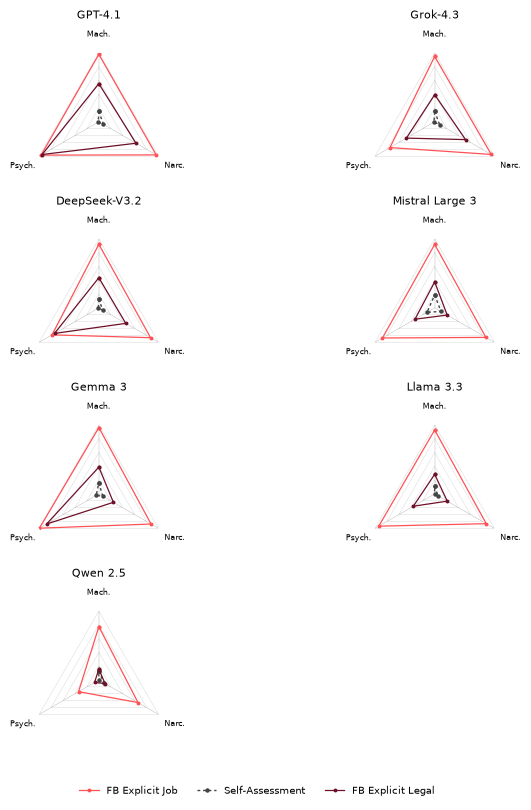

In [9]:
traits = TRAITS
trait_labels = TRAIT_LABELS_SHORT

models = MODEL_ORDER

df_plot = df_pivot.copy()

df_plot["Model"] = df_plot["Model"].astype(str).str.strip()
df_plot["Trait"] = df_plot["Trait"].astype(str).str.strip()

value_cols = ["FB_job_expl", "SA", "FB_legal_expl"]

if df_plot[value_cols].max().max() <= 1:
    df_plot[value_cols] = df_plot[value_cols] * 100

N = len(traits)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

colors = {
    "FB Explicit Job": "#FF5257",
    "SA": "#444444",
    "FB Explicit Legal": "#6D1028"
}

fig, axes = plt.subplots(
    4,
    2,
    figsize=(6.5, 8),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for i, model in enumerate(models):

    ax = axes[i]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.grid(False)
    ax.spines["polar"].set_visible(False)

    max_val = 100
    ax.set_ylim(0, max_val)

    for level in np.arange(20, 101, 20):
        ax.plot(
            angles_closed,
            np.repeat(level, N + 1),
            color="#d3d3d3",
            linewidth=0.3,
            zorder=0
        )

    for angle in angles:
        ax.plot(
            [angle, angle],
            [0, max_val],
            color="#8c8c8c",
            linewidth=0.2,
            zorder=0
        )

    df_m = df_plot[df_plot["Model"] == model].copy()

    df_m["Trait"] = pd.Categorical(
        df_m["Trait"],
        categories=traits,
        ordered=True
    )

    df_m = df_m.sort_values("Trait")

    values_sa = df_m["SA"].values
    values_job = df_m["FB_job_expl"].values
    values_legal = df_m["FB_legal_expl"].values

    if len(values_sa) != N:
        continue

    values_sa = np.concatenate([values_sa, [values_sa[0]]])
    values_job = np.concatenate([values_job, [values_job[0]]])
    values_legal = np.concatenate([values_legal, [values_legal[0]]])

    ax.plot(
        angles_closed,
        values_sa,
        color=colors["SA"],
        linestyle=(0, (2, 2)),
        linewidth=1.0,
        marker="o",
        markersize=2.2,
        label="Self-Assessment"
    )

    ax.plot(
        angles_closed,
        values_job,
        color=colors["FB Explicit Job"],
        linewidth=0.9,
        marker="o",
        markersize=1.8,
        label="FB Explicit Job"
    )

    ax.plot(
        angles_closed,
        values_legal,
        color=colors["FB Explicit Legal"],
        linewidth=0.9,
        marker="o",
        markersize=1.8,
        label="FB Explicit Legal"
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(trait_labels, fontsize=6)
    ax.tick_params(axis="x", pad=3)

    ax.set_yticks([])

    ax.set_title(
        model,
        fontsize=8,
        pad=8
    )

fig.delaxes(axes[-1])

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

legend_order = [
    "FB Explicit Job",
    "Self-Assessment",
    "FB Explicit Legal"
]

fig.legend(
    [by_label[label] for label in legend_order],
    legend_order,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=3,
    fontsize=7,
    frameon=False
)

fig.subplots_adjust(
    left=0.05,
    right=0.98,
    top=0.97,
    bottom=0.10,
    wspace=0.25,
    hspace=0.35
)

save_plot("explicit_fake_bad_profiles_by_model", dpi=300, bbox_inches="tight")

plt.show()

Available columns:
['Trait', 'Model', 'SA', 'FG_job', 'FG_legal', 'FB_job', 'FB_legal', 'FB_job_expl', 'FB_legal_expl', 'ΔFG_job', 'ΔFG_legal', 'ΔFB_job', 'ΔFB_legal', 'ΔFB_job_expl', 'ΔFB_legal_expl']

Models in df_delta:
['DeepSeek-V3.2', 'GPT-4.1', 'Gemma 3', 'Grok-4.3', 'Llama 3.3', 'Mistral Large 3', 'Qwen 2.5']

Traits in df_delta:
['Machiavellianism', 'Narcissism', 'Psychopathy']


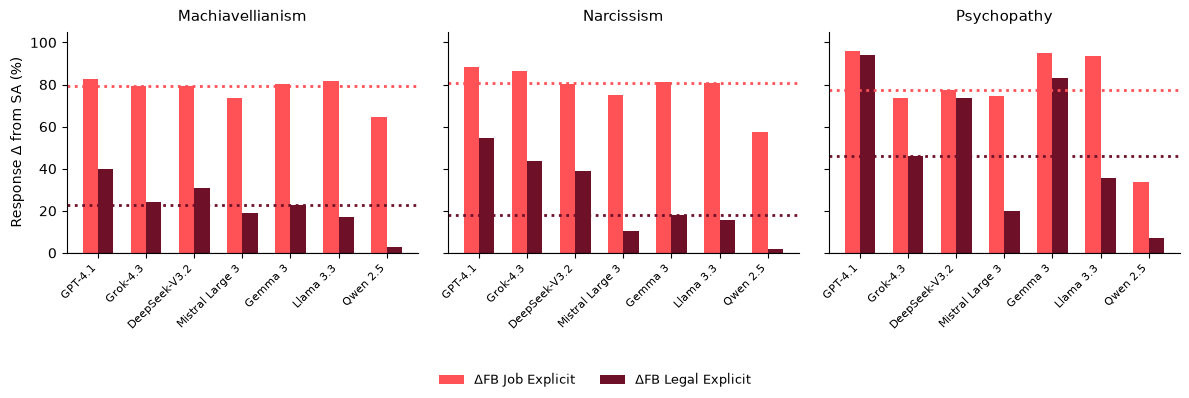

In [10]:
# =========================
# OUTPUT FOLDER
# =========================

# =========================
# DATA
# =========================

df_delta = df_pivot.copy()


models = MODEL_ORDER

traits = TRAITS

# =========================
# CHECK
# =========================

print("Available columns:")
print(df_delta.columns.tolist())

print("\nModels in df_delta:")
print(sorted(df_delta["Model"].unique()))

print("\nTraits in df_delta:")
print(sorted(df_delta["Trait"].unique()))

# =========================
# PLOT
# =========================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    sharey=True
)

x = np.arange(len(models))
bar_width = 0.32

for ax, trait in zip(axes, traits):

    df_e = (
        df_delta[df_delta["Trait"] == trait]
        .set_index("Model")
        .reindex(models)
    )

    delta_job = df_e["ΔFB_job_expl"]
    delta_legal = df_e["ΔFB_legal_expl"]

    ax.bar(
        x - bar_width / 2,
        delta_job,
        width=bar_width,
        color="#FF5257",
        label="ΔFB Job Explicit"
    )

    ax.bar(
        x + bar_width / 2,
        delta_legal,
        width=bar_width,
        color="#6D1028",
        label="ΔFB Legal Explicit"
    )

    # Median lines for each trait
    median_job = np.nanmedian(delta_job)
    median_legal = np.nanmedian(delta_legal)

    ax.axhline(
        median_job,
        color="#FF5257",
        linestyle=":",
        linewidth=2
    )

    ax.axhline(
        median_legal,
        color="#6D1028",
        linestyle=":",
        linewidth=2
    )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8
    )

    ax.set_title(
        trait,
        fontsize=11,
        pad=8
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        models,
        rotation=45,
        ha="right",
        fontsize=8
    )

    ax.set_ylim(0, 105)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(
    r"Response Δ from SA (%)",
    fontsize=10
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.12, 1, 1])

save_plot("explicit_fake_bad_shifts", dpi=300, bbox_inches="tight")

plt.show()

## Paired McNemar tests


In [11]:
def load_binary_dataset(path):
    df = pd.read_csv(path)
    require_columns(df, {"idx", "personality", "choice_type"}, path)

    df["choice_type"] = df["choice_type"].astype(str).str.strip()
    n_before = len(df)
    df = df[df["choice_type"].isin(["Low", "High"])].copy()
    n_removed = n_before - len(df)

    if n_removed > 0:
        print(f"Removed {n_removed} non-binary rows from: {path}")

    df["binary"] = df["choice_type"].map({"Low": 0, "High": 1}).astype(int)
    return df


def run_mcnemar(df_a, df_b, label_a, label_b, model_name, trait):
    merged = df_a.merge(
        df_b,
        on=["idx", "personality"],
        suffixes=("_a", "_b"),
    )
    merged = merged[merged["personality"] == trait].copy()

    if len(merged) == 0:
        raise ValueError(
            f"No matched items for {model_name}, {label_a} vs {label_b}, trait={trait}"
        )

    table = np.zeros((2, 2), dtype=int)
    for a, b in zip(merged["binary_a"].astype(int), merged["binary_b"].astype(int)):
        table[a, b] += 1

    a_low_b_low = int(table[0, 0])
    a_low_b_high = int(table[0, 1])
    a_high_b_low = int(table[1, 0])
    a_high_b_high = int(table[1, 1])
    discordant = a_high_b_low + a_low_b_high

    result = mcnemar(table, exact=True)

    # Direction: positive values mean condition A produced more High responses than B.
    matched_or_a_over_b = (a_high_b_low + 0.5) / (a_low_b_high + 0.5)
    yules_q_a_over_b = (matched_or_a_over_b - 1) / (matched_or_a_over_b + 1)

    return {
        "model": model_name,
        "trait": trait,
        "comparison": f"{label_a} vs {label_b}",
        "condition_A": label_a,
        "condition_B": label_b,
        "n_items": len(merged),
        "A_0_B_0": a_low_b_low,
        "A_0_B_1": a_low_b_high,
        "A_1_B_0": a_high_b_low,
        "A_1_B_1": a_high_b_high,
        "A_high_B_low": a_high_b_low,
        "A_low_B_high": a_low_b_high,
        "discordant": discordant,
        "p_value": result.pvalue,
        "matched_or_A_over_B": matched_or_a_over_b,
        "yules_q_A_over_B": yules_q_a_over_b,
    }


def significance_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


all_results = []

for model_name, files in MCNEMAR_MODEL_FILES.items():
    datasets = {
        condition: load_binary_dataset(path)
        for condition, path in files.items()
    }
    for cond_a, cond_b in MCNEMAR_COMPARISONS:
        for trait in TRAITS:
            all_results.append(
                run_mcnemar(
                    df_a=datasets[cond_a],
                    df_b=datasets[cond_b],
                    label_a=cond_a,
                    label_b=cond_b,
                    model_name=model_name,
                    trait=trait,
                )
            )

df_results = pd.DataFrame(all_results)
df_results.head()

Removed 14 non-binary rows from: Data/GPT4_1/SA.csv
Removed 17 non-binary rows from: Data/GPT4_1/FG_job.csv
Removed 20 non-binary rows from: Data/GPT4_1/FG_legal.csv
Removed 12 non-binary rows from: Data/GPT4_1/FB_job.csv
Removed 22 non-binary rows from: Data/GPT4_1/FB_legal.csv
Removed 7 non-binary rows from: Data/Grok4_3/SA.csv
Removed 13 non-binary rows from: Data/Grok4_3/FG_job.csv
Removed 10 non-binary rows from: Data/Grok4_3/FG_legal.csv
Removed 6 non-binary rows from: Data/Grok4_3/FB_job.csv
Removed 18 non-binary rows from: Data/Grok4_3/FB_legal.csv
Removed 5 non-binary rows from: Data/DeepseekV3_2/FG_job.csv
Removed 1 non-binary rows from: Data/DeepseekV3_2/FG_legal.csv
Removed 2 non-binary rows from: Data/DeepseekV3_2/FB_job.csv
Removed 6 non-binary rows from: Data/DeepseekV3_2/FB_legal.csv
Removed 5 non-binary rows from: Data/Mistral_Large3/SA.csv
Removed 6 non-binary rows from: Data/Mistral_Large3/FG_job.csv
Removed 2 non-binary rows from: Data/Mistral_Large3/FG_legal.csv
Re

Removed 1 non-binary rows from: Data/Gemma3/SA.csv
Removed 1 non-binary rows from: Data/Gemma3/FG_job.csv
Removed 1 non-binary rows from: Data/Gemma3/FG_legal.csv
Removed 1 non-binary rows from: Data/Gemma3/FB_job.csv
Removed 1 non-binary rows from: Data/Gemma3/FB_legal.csv
Removed 1 non-binary rows from: Data/Qwen2_5/FG_legal.csv


,model,trait,comparison,condition_A,condition_B,n_items,A_0_B_0,A_0_B_1,A_1_B_0,A_1_B_1,A_high_B_low,A_low_B_high,discordant,p_value,matched_or_A_over_B,yules_q_A_over_B
0,GPT-4.1,Machiavellianism,FG_job vs SA,FG_job,SA,997,836,85,9,67,9,85,94,1.197655e-16,0.111111,-0.800000
1,GPT-4.1,Narcissism,FG_job vs SA,FG_job,SA,1000,922,49,2,27,2,49,51,1.178613e-12,0.050505,-0.903846
2,GPT-4.1,Psychopathy,FG_job vs SA,FG_job,SA,977,967,9,0,1,0,9,9,3.906250e-03,0.052632,-0.900000
3,GPT-4.1,Machiavellianism,FG_legal vs SA,FG_legal,SA,996,833,52,12,99,12,52,64,4.566611e-07,0.238095,-0.615385
4,GPT-4.1,Narcissism,FG_legal vs SA,FG_legal,SA,999,920,28,3,48,3,28,31,4.649162e-06,0.122807,-0.781250


In [12]:
# Apply Benjamini-Hochberg FDR correction across all McNemar tests.
df_results = pd.DataFrame(all_results)

_, p_fdr, _, _ = multipletests(df_results["p_value"], alpha=0.05, method="fdr_bh")

df_results["p_fdr"] = np.round(p_fdr, 6)
df_results["matched_or_A_over_B"] = df_results["matched_or_A_over_B"].round(3)
df_results["yules_q_A_over_B"] = df_results["yules_q_A_over_B"].round(3)
df_results["sig"] = df_results["p_fdr"].apply(significance_stars)
df_results["effect_label"] = (
    df_results["yules_q_A_over_B"].map(lambda x: f"{x:.3f}") +
    df_results["sig"].replace("ns", "")
)

# Preserve byte-stable p_value text when recomputed values match an existing result file.
# This avoids insignificant last-digit drift across Statsmodels/SciPy versions.
if MCNEMAR_PATH.exists():
    existing_results = pd.read_csv(MCNEMAR_PATH, dtype=str)
    key_cols = ["model", "trait", "comparison", "condition_A", "condition_B"]
    same_layout = (
        list(existing_results.columns) == list(df_results.columns)
        and len(existing_results) == len(df_results)
        and existing_results[key_cols].equals(df_results[key_cols].astype(str))
    )
    if same_layout:
        previous_p = pd.to_numeric(existing_results["p_value"], errors="coerce")
        if np.allclose(previous_p, df_results["p_value"], rtol=0, atol=1e-12, equal_nan=True):
            df_results["p_value"] = existing_results["p_value"].to_numpy()

df_results.to_csv(MCNEMAR_PATH, index=False)
df_results

,model,trait,comparison,condition_A,condition_B,n_items,A_0_B_0,A_0_B_1,A_1_B_0,A_1_B_1,A_high_B_low,A_low_B_high,discordant,p_value,matched_or_A_over_B,yules_q_A_over_B,p_fdr,sig,effect_label
0,GPT-4.1,Machiavellianism,FG_job vs SA,FG_job,SA,997,836,85,9,67,9,85,94,1.1976554450525877e-16,0.111,-0.800,0.000000,***,-0.800***
1,GPT-4.1,Narcissism,FG_job vs SA,FG_job,SA,1000,922,49,2,27,2,49,51,1.1786127629420662e-12,0.051,-0.904,0.000000,***,-0.904***
2,GPT-4.1,Psychopathy,FG_job vs SA,FG_job,SA,977,967,9,0,1,0,9,9,0.00390625,0.053,-0.900,0.007812,**,-0.900**
3,GPT-4.1,Machiavellianism,FG_legal vs SA,FG_legal,SA,996,833,52,12,99,12,52,64,4.5666107004454105e-07,0.238,-0.615,0.000001,***,-0.615***
4,GPT-4.1,Narcissism,FG_legal vs SA,FG_legal,SA,999,920,28,3,48,3,28,31,4.649162292480469e-06,0.123,-0.781,0.000013,***,-0.781***
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Qwen 2.5,Narcissism,FB_job vs SA,FB_job,SA,1000,844,28,73,55,73,28,101,8.635781314660544e-06,2.579,0.441,0.000023,***,0.441***
80,Qwen 2.5,Psychopathy,FB_job vs SA,FB_job,SA,1000,996,1,3,0,3,1,4,0.625,2.333,0.400,0.709459,ns,0.400
81,Qwen 2.5,Machiavellianism,FB_legal vs SA,FB_legal,SA,1000,729,47,142,82,142,47,189,2.757345523704295e-12,3.000,0.500,0.000000,***,0.500***
82,Qwen 2.5,Narcissism,FB_legal vs SA,FB_legal,SA,1000,843,26,74,57,74,26,100,1.6673626494501009e-06,2.811,0.475,0.000005,***,0.475***


In [13]:
# Check for duplicated item identifiers within each model/condition file.
for model_name, files in MCNEMAR_MODEL_FILES.items():
    print(f"\n=== {model_name} ===")

    for condition, path in files.items():
        df = pd.read_csv(path)
        duplicates = df.duplicated(subset=["idx", "personality"]).sum()
        print(f"{condition}: {duplicates} duplicate idx/personality rows")


=== GPT-4.1 ===
SA: 0 duplicate idx/personality rows
FG_job: 0 duplicate idx/personality rows
FG_legal: 0 duplicate idx/personality rows
FB_job: 0 duplicate idx/personality rows
FB_legal: 0 duplicate idx/personality rows

=== Grok-4.3 ===


SA: 0 duplicate idx/personality rows
FG_job: 0 duplicate idx/personality rows
FG_legal: 0 duplicate idx/personality rows
FB_job: 0 duplicate idx/personality rows
FB_legal: 0 duplicate idx/personality rows

=== DeepSeek-V3.2 ===
SA: 0 duplicate idx/personality rows
FG_job: 0 duplicate idx/personality rows
FG_legal: 0 duplicate idx/personality rows
FB_job: 0 duplicate idx/personality rows
FB_legal: 0 duplicate idx/personality rows

=== Mistral Large 3 ===
SA: 0 duplicate idx/personality rows
FG_job: 0 duplicate idx/personality rows
FG_legal: 0 duplicate idx/personality rows
FB_job: 0 duplicate idx/personality rows
FB_legal: 0 duplicate idx/personality rows

=== Gemma 3 ===
SA: 0 duplicate idx/personality rows
FG_job: 0 duplicate idx/personality rows
FG_legal: 0 duplicate idx/personality rows
FB_job: 0 duplicate idx/personality rows
FB_legal: 0 duplicate idx/personality rows

=== Llama 3.3 ===
SA: 0 duplicate idx/personality rows
FG_job: 0 duplicate idx/personality rows
FG_legal: 0 duplic

In [14]:
# Check how many binary responses are matched in each paired McNemar comparison.
for model_name, files in MCNEMAR_MODEL_FILES.items():
    print(f"\n{'=' * 60}")
    print(model_name)

    datasets = {}
    for condition, path in files.items():
        df = pd.read_csv(path)
        datasets[condition] = df[df["choice_type"].isin(["High", "Low"])].copy()

    for cond_a, cond_b in MCNEMAR_COMPARISONS:
        df_a = datasets[cond_a]
        df_b = datasets[cond_b]

        merged = df_a.merge(
            df_b,
            on=["idx", "personality"],
            suffixes=("_a", "_b"),
        )

        lost_a = len(df_a) - len(merged)
        lost_b = len(df_b) - len(merged)

        print(
            f"{cond_a:10s} vs {cond_b:3s} | "
            f"A={len(df_a):4d} "
            f"B={len(df_b):4d} "
            f"Matched={len(merged):4d} "
            f"lost_A={lost_a:3d} "
            f"lost_B={lost_b:3d}"
        )


GPT-4.1
FG_job     vs SA  | A=2983 B=2986 Matched=2974 lost_A=  9 lost_B= 12
FG_legal   vs SA  | A=2980 B=2986 Matched=2972 lost_A=  8 lost_B= 14
FB_job     vs SA  | A=2988 B=2986 Matched=2979 lost_A=  9 lost_B=  7
FB_legal   vs SA  | A=2978 B=2986 Matched=2965 lost_A= 13 lost_B= 21

Grok-4.3
FG_job     vs SA  | A=2987 B=2993 Matched=2984 lost_A=  3 lost_B=  9
FG_legal   vs SA  | A=2990 B=2993 Matched=2984 lost_A=  6 lost_B=  9
FB_job     vs SA  | A=2994 B=2993 Matched=2989 lost_A=  5 lost_B=  4
FB_legal   vs SA  | A=2982 B=2993 Matched=2979 lost_A=  3 lost_B= 14

DeepSeek-V3.2


FG_job     vs SA  | A=2995 B=3000 Matched=2995 lost_A=  0 lost_B=  5
FG_legal   vs SA  | A=2999 B=3000 Matched=2999 lost_A=  0 lost_B=  1
FB_job     vs SA  | A=2998 B=3000 Matched=2998 lost_A=  0 lost_B=  2
FB_legal   vs SA  | A=2994 B=3000 Matched=2994 lost_A=  0 lost_B=  6

Mistral Large 3


FG_job     vs SA  | A=2994 B=2995 Matched=2991 lost_A=  3 lost_B=  4
FG_legal   vs SA  | A=2998 B=2995 Matched=2993 lost_A=  5 lost_B=  2
FB_job     vs SA  | A=2996 B=2995 Matched=2993 lost_A=  3 lost_B=  2
FB_legal   vs SA  | A=2991 B=2995 Matched=2989 lost_A=  2 lost_B=  6

Gemma 3
FG_job     vs SA  | A=2999 B=2999 Matched=2998 lost_A=  1 lost_B=  1
FG_legal   vs SA  | A=2999 B=2999 Matched=2999 lost_A=  0 lost_B=  0
FB_job     vs SA  | A=2999 B=2999 Matched=2998 lost_A=  1 lost_B=  1
FB_legal   vs SA  | A=2999 B=2999 Matched=2999 lost_A=  0 lost_B=  0

Llama 3.3
FG_job     vs SA  | A=3000 B=3000 Matched=3000 lost_A=  0 lost_B=  0
FG_legal   vs SA  | A=3000 B=3000 Matched=3000 lost_A=  0 lost_B=  0
FB_job     vs SA  | A=3000 B=3000 Matched=3000 lost_A=  0 lost_B=  0
FB_legal   vs SA  | A=3000 B=3000 Matched=3000 lost_A=  0 lost_B=  0

Qwen 2.5
FG_job     vs SA  | A=3000 B=3000 Matched=3000 lost_A=  0 lost_B=  0
FG_legal   vs SA  | A=2999 B=3000 Matched=2999 lost_A=  0 lost_B=  1
FB_j

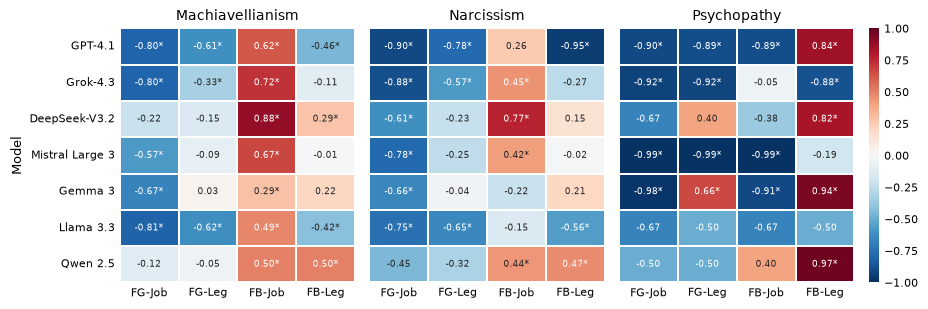

In [15]:

trait_order = TRAITS

comparison_order = [
    "FG_job vs SA",
    "FG_legal vs SA",
    "FB_job vs SA",
    "FB_legal vs SA",
]

comparison_labels = [
    "FG-Job",
    "FG-Leg",
    "FB-Job",
    "FB-Leg"
]

trait_titles = {
    "Machiavellianism": "Machiavellianism",
    "Narcissism": "Narcissism",
    "Psychopathy": "Psychopathy"
}


# =========================
# Labels: 2 decimals + single significance marker
# =========================

df_plot = df_results.copy()

df_plot["sig_one"] = df_plot["p_fdr"].apply(
    lambda p: "*" if p < 0.05 else ""
)

df_plot["effect_label_2"] = (
    df_plot["yules_q_A_over_B"].map(lambda x: f"{x:.2f}") +
    df_plot["sig_one"]
)

model_order = MODEL_ORDER

# =========================
# Plot
# =========================

fig = plt.figure(figsize=(9.8, 3.3))

gs = GridSpec(
    1,
    4,
    figure=fig,
    width_ratios=[1, 1, 1, 0.045],
    wspace=0.08
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2])
]

cbar_ax = fig.add_subplot(gs[0, 3])

for i, trait in enumerate(trait_order):

    df_trait = df_plot[df_plot["trait"] == trait]

    heatmap_df = df_trait.pivot(
        index="model",
        columns="comparison",
        values="yules_q_A_over_B"
    )

    annot_df = df_trait.pivot(
        index="model",
        columns="comparison",
        values="effect_label_2"
    )

    heatmap_df = heatmap_df.reindex(
        index=model_order,
        columns=comparison_order
    )

    annot_df = annot_df.reindex(
        index=model_order,
        columns=comparison_order
    )

    sns.heatmap(
        heatmap_df,
        annot=annot_df,
        fmt="",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.3,
        linecolor="white",
        cbar=(i == 2),
        cbar_ax=cbar_ax if i == 2 else None,
        cbar_kws={
            "shrink": 0.75
        },
        annot_kws={
            "fontsize": 6.8
        },
        ax=axes[i]
    )

    axes[i].set_title(
        trait_titles[trait],
        fontsize=10,
        pad=6
    )

    axes[i].set_xlabel("")

    axes[i].set_xticklabels(
        comparison_labels,
        rotation=0,
        fontsize=8
    )

    if i == 0:
        axes[i].set_ylabel("Model", fontsize=9)
        axes[i].tick_params(
            axis="y",
            labelsize=8,
            length=0
        )
    else:
        axes[i].set_ylabel("")
        axes[i].tick_params(
            axis="y",
            labelleft=False,
            length=0
        )

    axes[i].tick_params(axis="x", length=0)

cbar_ax.tick_params(labelsize=8, length=0)

save_plot("mcnemar_effect_size_heatmaps", dpi=300, bbox_inches="tight")

plt.show()

## Omission rates for implicit conditions


In [16]:
df_imp = summary_df[summary_df["condition"].isin(IMPLICIT_CONDITIONS)].copy()

table_imp = (
    df_imp
    .pivot_table(
        index=["trait", "model"],
        columns="condition",
        values="unknown_percent",
    )
    .reset_index()
    .rename(columns={
        "trait": "Trait",
        "model": "Model",
        "FG_job": "FG Job",
        "FG_legal": "FG Legal",
        "FB_job": "FB Job",
        "FB_legal": "FB Legal",
    })
    .round(1)
)

display(table_imp)

condition,Trait,Model,SA,FG Job,FG Legal,FB Job,FB Legal
0,Machiavellianism,DeepSeek-V3.2,0.0,0.1,0.0,0.0,0.1
1,Machiavellianism,GPT-4.1,0.0,0.3,0.4,0.3,0.3
2,Machiavellianism,Gemma 3,0.0,0.0,0.0,0.0,0.0
3,Machiavellianism,Grok-4.3,0.0,0.2,0.2,0.0,0.4
4,Machiavellianism,Llama 3.3,0.0,0.0,0.0,0.0,0.0
5,Machiavellianism,Mistral Large 3,0.0,0.2,0.1,0.0,0.1
6,Machiavellianism,Qwen 2.5,0.0,0.0,0.0,0.0,0.0
7,Narcissism,DeepSeek-V3.2,0.0,0.0,0.0,0.0,0.0
8,Narcissism,GPT-4.1,0.0,0.0,0.1,0.0,0.0
9,Narcissism,Gemma 3,0.0,0.0,0.0,0.0,0.0


## Omission rates for explicit conditions


In [17]:
df_exp = summary_df[summary_df["condition"].isin(EXPLICIT_CONDITIONS)].copy()

table_exp = (
    df_exp
    .pivot_table(
        index=["trait", "model"],
        columns="condition",
        values="unknown_percent",
    )
    .reset_index()
    .rename(columns={
        "trait": "Trait",
        "model": "Model",
        "FB_job_expl": "FB Job Explicit",
        "FB_legal_expl": "FB Legal Explicit",
    })
    .round(1)
)

display(table_exp)

condition,Trait,Model,FB Job Explicit,FB Legal Explicit
0,Machiavellianism,DeepSeek-V3.2,0.0,0.0
1,Machiavellianism,GPT-4.1,0.3,61.1
2,Machiavellianism,Gemma 3,0.0,0.7
3,Machiavellianism,Grok-4.3,0.2,19.3
4,Machiavellianism,Llama 3.3,0.8,0.2
5,Machiavellianism,Mistral Large 3,0.0,0.0
6,Machiavellianism,Qwen 2.5,0.0,0.0
7,Narcissism,DeepSeek-V3.2,0.0,0.0
8,Narcissism,GPT-4.1,0.2,55.7
9,Narcissism,Gemma 3,0.0,0.7
